

# **Import Liabraries**


In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# **Load dataset**

In [154]:
df= pd.read_csv('Indian_Resturants.csv')

# **Dataset**

In [155]:
df

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211939,3202251,Kali Mirch Cafe And Restaurant,['Casual Dining'],https://www.zomato.com/vadodara/kali-mirch-caf...,"Manu Smriti Complex, Near Navrachna School, GI...",Vadodara,32,Fatehgunj,22.336931,73.192356,...,2,Rs.,"['Dinner', 'Cash', 'Lunch', 'Delivery', 'Indoo...",4.1,Very Good,243,40,0.0,-1,-1
211940,3200996,Raju Omlet,['Quick Bites'],https://www.zomato.com/vadodara/raju-omlet-kar...,"Mahalaxmi Apartment, Opposite B O B, Karoli Ba...",Vadodara,32,Karelibaug,22.322455,73.197203,...,1,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.1,Very Good,187,40,0.0,1,-1
211941,18984164,The Grand Thakar,['Casual Dining'],https://www.zomato.com/vadodara/the-grand-thak...,"3rd Floor, Shreem Shalini Mall, Opposite Conqu...",Vadodara,32,Alkapuri,22.310563,73.171164,...,2,Rs.,"['Dinner', 'Cash', 'Debit Card', 'Lunch', 'Tak...",4.0,Very Good,111,38,0.0,-1,-1
211942,3201138,Subway,['Quick Bites'],https://www.zomato.com/vadodara/subway-1-akota...,"G-2, Vedant Platina, Near Cosmos, Akota, Vadodara",Vadodara,32,Akota,22.270027,73.143068,...,2,Rs.,"['Dinner', 'Delivery', 'Credit Card', 'Lunch',...",3.7,Good,128,34,0.0,1,-1


# **Data overview**

---




**Data shape**

In [156]:
df.shape

(211944, 26)

**Data Types of columns**

In [157]:
df.dtypes

,0
res_id,int64
name,object
establishment,object
url,object
address,object
city,object
city_id,int64
locality,object
latitude,float64
longitude,float64


 **Null values in column**

In [158]:
df.isnull().sum()

,0
res_id,0
name,0
establishment,0
url,0
address,134
city,0
city_id,0
locality,0
latitude,0
longitude,0


 **let's fix address and opentable support column**

In [159]:
df['address']=df['address'].fillna('unknown')
df['opentable_support']= df['opentable_support'].fillna('0.0')

 **Remove unnecessary columns**

In [160]:
df.drop('zipcode',axis=1,inplace=True )
df.drop('currency',axis=1,inplace=True )
df.drop('latitude',axis=1,inplace=True )
df.drop('longitude',axis=1,inplace=True )

 **Remove duplicates**

In [161]:
df.drop_duplicates('res_id',inplace=True)

 **Drop null values**

In [162]:
df.dropna(inplace=True)

In [163]:
df['highlights']=df['highlights'].str.lower()

**create a new column based on alcohol Availability**

In [164]:
import numpy as np

df['alcohol'] = np.where(
    df['highlights'].str.contains('no alcohol|no alcohol available', case=False, na=False),
    'no',
    np.where(
        df['highlights'].str.contains('alcohol|serves alcohol|beer|wine', case=False, na=False),
        'yes',
        'no'
    )
)

In [165]:
df


,res_id,name,establishment,url,address,city,city_id,locality,country_id,locality_verbose,...,price_range,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway,alcohol
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,1,"Khandari, Agra",...,2,"['lunch', 'takeaway available', 'credit card',...",4.4,Very Good,814,154,0.0,-1,-1,no
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,1,"Agra Cantt, Agra",...,2,"['delivery', 'no alcohol available', 'dinner',...",4.4,Very Good,1203,161,0.0,-1,-1,no
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,1,"Shahganj, Agra",...,1,"['no alcohol available', 'dinner', 'takeaway a...",4.2,Very Good,801,107,0.0,1,-1,no
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,1,"Civil Lines, Agra",...,1,"['takeaway available', 'credit card', 'lunch',...",4.3,Very Good,693,157,0.0,1,-1,no
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,1,"Tajganj, Agra",...,3,"['lunch', 'serves alcohol', 'cash', 'credit ca...",4.9,Excellent,470,291,0.0,1,-1,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211882,19142822,Shree Janta Ice Cream,['Dessert Parlour'],https://www.zomato.com/vadodara/shree-janta-ic...,"Ground Floor, 5 Ronak Plaza, Tulsidham Char Ra...",Vadodara,32,Manjalpur,1,"Manjalpur, Vadodara",...,1,"['cash', 'takeaway available', 'delivery', 'in...",2.9,Average,4,1,0.0,1,-1,no
211925,18984164,The Grand Thakar,['Casual Dining'],https://www.zomato.com/vadodara/the-grand-thak...,"3rd Floor, Shreem Shalini Mall, Opposite Conqu...",Vadodara,32,Alkapuri,1,"Alkapuri, Vadodara",...,2,"['dinner', 'cash', 'debit card', 'lunch', 'tak...",4.0,Very Good,111,38,0.0,-1,-1,no
211926,18019952,Geeta lodge,['Casual Dining'],https://www.zomato.com/vadodara/geeta-lodge-al...,"Shop 11, Ground Floor, Atlantis K-10, Tower A,...",Vadodara,32,Alkapuri,1,"Alkapuri, Vadodara",...,1,"['dinner', 'cash', 'credit card', 'lunch', 'ta...",3.9,Good,207,14,0.0,-1,-1,no
211940,3200996,Raju Omlet,['Quick Bites'],https://www.zomato.com/vadodara/raju-omlet-kar...,"Mahalaxmi Apartment, Opposite B O B, Karoli Ba...",Vadodara,32,Karelibaug,1,"Karelibaug, Vadodara",...,1,"['dinner', 'cash', 'takeaway available', 'debi...",4.1,Very Good,187,40,0.0,1,-1,no


# **Calculate and visualize the average rating of restaurants**

In [166]:
avg_rating = df['aggregate_rating'].mean()
print(avg_rating)


2.997055135533837


/tmp/ipykernel_401/1068856026.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


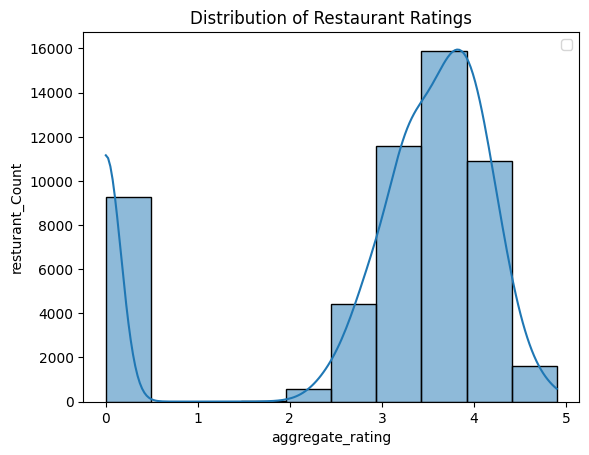

In [167]:
sns.histplot(df['aggregate_rating'], bins=10, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('aggregate_rating')
plt.ylabel('resturant_Count')
plt.legend()
plt.show()

#
* Most restaurants are highly rated, with ratings concentrated between 3.5 and 4.5.
* The distribution peaks around a rating of 4.0, indicating that most restaurants receive good customer feedback.
* A noticeable spike at 0 rating suggests many restaurants have not been rated yet or have missing customer reviews.
* Very few restaurants have ratings below 2.5, implying that poorly rated restaurants are relatively uncommon in the dataset.

# **Top Cities Who Has Hightest Number Of Resturants**

In [168]:
df.city.value_counts().head(10)

,count
city,
Bangalore,2245
Mumbai,2022
Pune,1841
Chennai,1827
New Delhi,1704
Jaipur,1393
Kolkata,1360
Ahmedabad,1245
Goa,1143


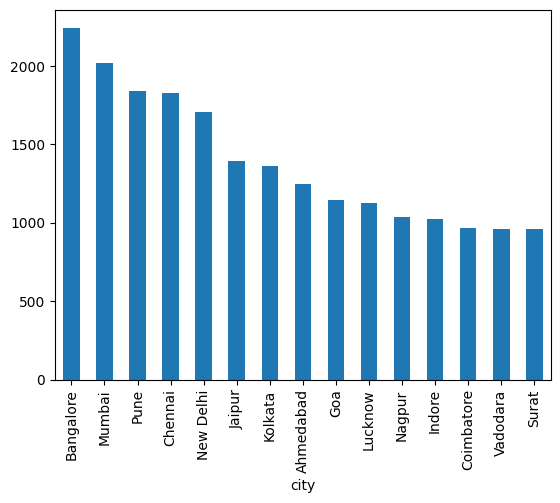

In [169]:

city_counts = df['city'].value_counts().head(15).plot(kind='bar')



#
* Bangalore has the highest number of restaurants in the dataset, followed closely by mumbai, making them the leading cities in terms of restaurant presence.
* Pune ranks third, while cities like new delhi, Jaipur, Kolkata and Ahmedabad also have a strong restaurant presence with over 1,200 establishments each.


   # **Most Popular Cuisines**

---



In [170]:
df['cuisines'].value_counts()

,count
cuisines,
North Indian,4192
Fast Food,1974
"North Indian, Chinese",1609
Bakery,1551
South Indian,1465
...,...
"Burger, Beverages, Cafe, Sandwich, Pizza, Bakery, Coffee",1
"Cafe, Chinese, Fast Food, Beverages, Desserts",1
"Cafe, Mexican, Italian, Fast Food",1


  **Visualize Top 10 Cuisines in list**



<Axes: xlabel='cuisines'>

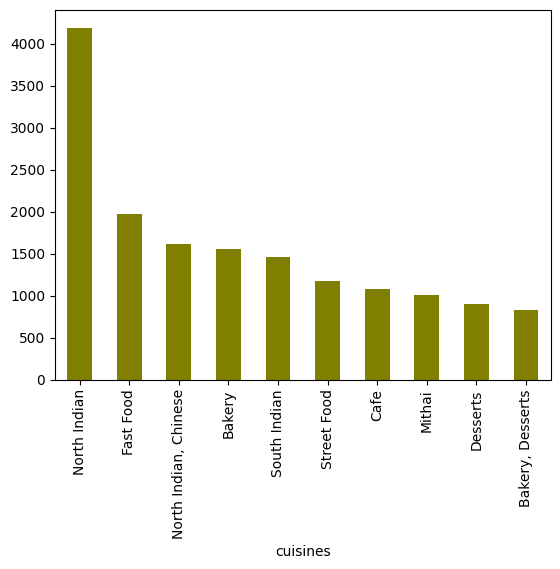

In [171]:
df['cuisines'].value_counts().head(10).plot(kind='bar',color='olive')

#
*  North Indian cuisine is the most popular, with over 2,400 restaurants, significantly outperforming all other cuisines in the dataset.
*  Fast food is the second most common cuisine combination, indicating a strong customer preference for fast food restaurants.
*  chinese, Bakery, and South Indian cuisines also have a substantial presence, making them among the most preferred food categories after North Indian cuisine.

# **Analyze the relationship between price range and restaurant ratings**

/tmp/ipykernel_401/827853198.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='price_range',y='aggregate_rating',palette='magma')


<Axes: xlabel='price_range', ylabel='aggregate_rating'>

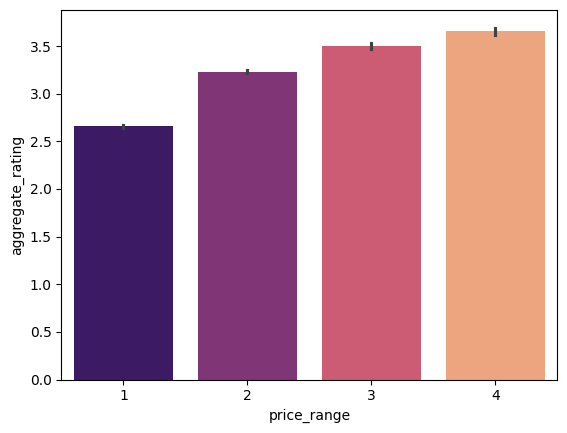

In [172]:
sns.barplot(data=df,x='price_range',y='aggregate_rating',palette='magma')

#

*   it shows positive correlation between "aggregate rating" and "price range".
*   it means ratings increases when price range increase.
  
*   restaurants in higher price brackets generally receive better ratings than those in lower price brackets.




# **The Top Restaurant Chains Based On The Number Of Outlets**

---



In [173]:
top_chains=df['name'].value_counts().head(10)


<Axes: xlabel='name'>

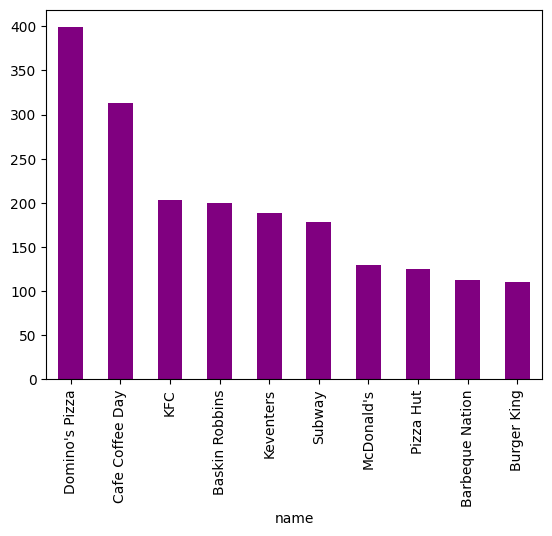

In [174]:
df['name'].value_counts().head(10).plot(kind='bar',color='purple')

#


*   Domino's Pizza has the highest number of outlets With around 180+ outlets, Domino's is the most represented restaurant chain in the dataset.
*   Cafe Coffee Day ranks second indicates that coffee chains also have a significant market presence.


*   Dessert brands like Baskin Robbins and Keventers also feature among the top 10.



# **Distribution of restaurants according to alcohol vailability**

<Axes: ylabel='count'>

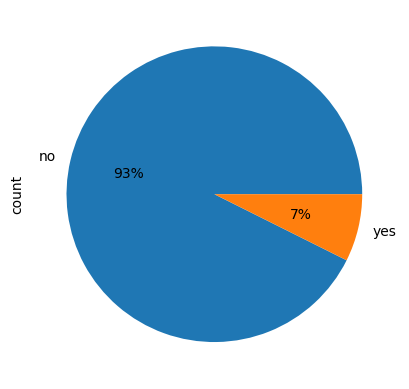

In [175]:
df['alcohol'].value_counts().plot(kind='pie' , autopct='%1.0f%%')

* It shows 93% of the restaurants do  not serve  ALCOHOL.
* The restaurant industry in the dataset is heavily dominated by non-alcohol-serving outlets.

# **Restaurant Count by Establishment Type**

In [176]:
df['establishment'].value_counts()


,count
establishment,
['Quick Bites'],13829
['Casual Dining'],11838
['Café'],4041
['Bakery'],3674
['Dessert Parlour'],3623
['Sweet Shop'],2569
['Beverage Shop'],2396
[],1638
['Fine Dining'],1493


/tmp/ipykernel_401/95463222.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='establishment',palette='inferno')


<Axes: xlabel='count', ylabel='establishment'>

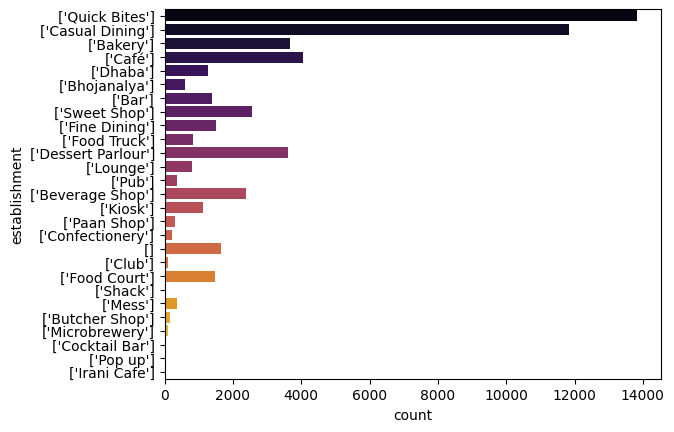

In [177]:

sns.countplot(data=df,y='establishment',palette='inferno')

#
* Quick Bites dominate the restaurant market, with nearly 13,829 establishments.
* Casual Dining is the second most prevalent establishment type, with over 11,838 restaurants.
* Specialized formats such as Cafés, Bakeries, Dessert Parlours, and Sweet Shops have a moderate presence.
* Premium and niche establishment types—including Fine Dining, Microbreweries, Cocktail Bars, Clubs, and Pop-up restaurants—represent only a small fraction of the dataset.

 # **Impact of Delivery Availability on Ratings**

In [178]:
delivery_rating_counts = df.groupby(['delivery', 'aggregate_rating']).size().unstack(fill_value=0)
delivery_rating_counts

aggregate_rating,0.0,1.8,1.9,2.0,2.1,2.2,2.3,2.4,2.5,2.6,...,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9
delivery,,,,,,,,,,,,,,,,,,,,,
-1,8122,2,4,9,23,45,120,223,300,429,...,1776,1456,1197,856,588,398,231,146,83,99
0,55,0,0,0,0,1,1,2,1,3,...,10,16,10,0,7,5,2,1,2,0
1,1095,0,0,1,5,19,45,71,93,135,...,1508,1270,982,752,471,277,194,91,57,31


<Figure size 2000x1000 with 0 Axes>

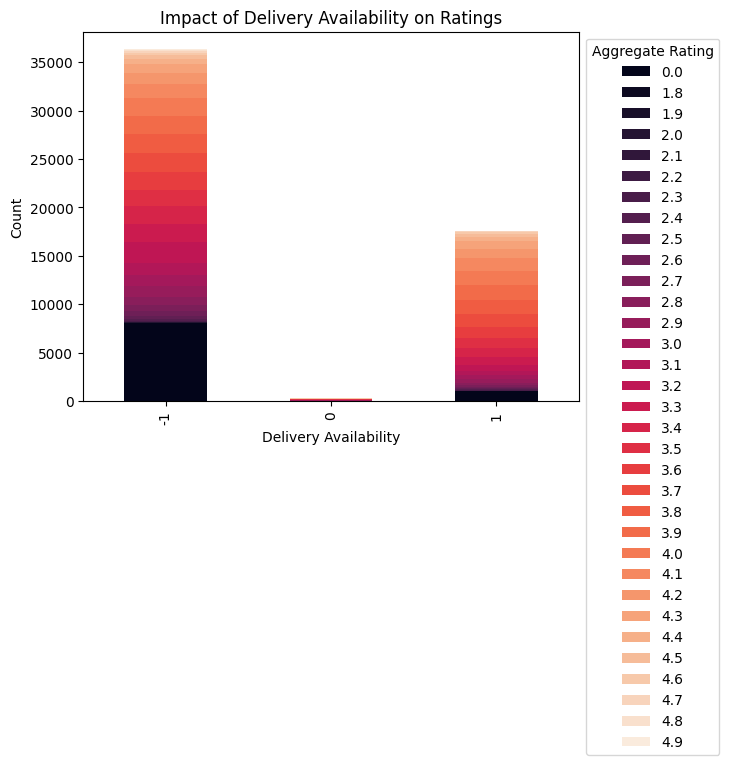

In [179]:
plt.figure(figsize=(20, 10))
delivery_rating_counts.plot(kind='bar', stacked=True, cmap='rocket')
plt.title('Impact of Delivery Availability on Ratings')
plt.xlabel('Delivery Availability')
plt.ylabel('Count')
plt.legend(title='Aggregate Rating', bbox_to_anchor=( 1,1))
plt.show()